In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
%matplotlib inline

import graph_tool.all as gt
import networkx as nx
import random
import math

In [2]:
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community import louvain_communities

## Load Network

Make sure you load the data from: "https://snap.stanford.edu/data/email-Eu-core.html" and update the paths in the code cell below:
- `path_to_edges_data`
- `path_to_labels_data`

then, we load the network, both as a Graph object using the `networkx` library and as a Graph object using the `graph-tool` library.

We load the network as a directed network since, from the network description,

"*There is an edge (u, v) in the network if person u sent person v at least one email.*"

(Note: the following analysis would be very similar for undirected networks as well!)

In [3]:
# laod data from: https://snap.stanford.edu/data/email-Eu-core.html
path_to_edges_data = '/Users/ec627/Documents/Data/FunDatasets/email-Eu-core.txt'
path_to_labels_data = '/Users/ec627/Documents/Data/FunDatasets/email-Eu-core-department-labels.txt'
edge_list_email_g = np.loadtxt(path_to_edges_data, delimiter=' ', dtype=int)
labels_email_g = np.loadtxt(path_to_labels_data, delimiter=' ', dtype=int)
ground_truth_b = np.array(labels_email_g[:,1])
ground_truth_b_dict = {row[0]: row[1] for row in labels_email_g}

# create Graph using networkx
email_nx = nx.DiGraph()
email_nx.add_edges_from(edge_list_email_g)
N = email_nx.number_of_nodes()
L = email_nx.number_of_edges()

# create Graph using graph-tool
email_gt = gt.Graph(directed = True)
email_gt.add_edge_list(edge_list_email_g)

print('This is the networkx graph object:')
print(email_nx)
print('\nThis is the graph-tool graph object:')
print(email_gt)

This is the networkx graph object:
DiGraph with 1005 nodes and 25571 edges

This is the graph-tool graph object:
<Graph object, directed, with 1005 vertices and 25571 edges, at 0x179998980>


### Prelimiary Analysis

Since we are dealing with some real world data, let's have a look at our network.

Is the network strongly connected? Is it weakly connected? What should we choose to study the community structure of the network?

In [4]:
# Let's do a preliminary analysis
print('Network Summary:')
print('- Nodes: {:.0f}'.format(N))
print('- Edges: {:.0f}'.format(L))

# let's compute the number of components using networkx
# note, the graph is directed, so we can either compute the strongly connected component or the weakly connected component
# start with strongly connected component:
cc = list(nx.strongly_connected_components(email_nx)) # this stores a list of sets, each being the set of nodes in a connected component
size_components = [len(c) for c in sorted(cc, key=len, reverse=True)]
singletons = np.array([], dtype = int)
for c in cc:
    if len(c) == 1:
        singletons = np.append(singletons, list(c))

# below we create a subgraph for the giant connected component
gcc = list(max(nx.strongly_connected_components(email_nx), key=len))
email_nx_gcc = email_nx.subgraph(gcc).copy()

###################################
print('\nComponent sizes:')
print(size_components)
print('we see that there is one giant component and {:.0f} sigletons'.format(len(singletons)))
print('the singleton nodes are:')
print(np.sort(singletons))

# note, this subgrah keeps the same node labels as the full graph, but it doesn't include the singletons:
# e.g.,
print('\nGiant Connected component subgraph (`email_nx_gcc`):')
print(email_nx_gcc)
print('- does it contain singleton 468? ', email_nx_gcc.has_node(468))
print('- does it contain first node 0? ', email_nx_gcc.has_node(0))
print('- does it contain last node (non-removed) 1003? ', email_nx_gcc.has_node(1003))

# finally, we collect the labels of the nodes in the gcc for later analysis:
# ground_truth_b_gcc = ground_truth_b[list(cc[0])]

Network Summary:
- Nodes: 1005
- Edges: 25571

Component sizes:
[803, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
we see that there is one giant component and 202 sigletons
the singleton nodes are:
[   1   78  130  203  227  239  289  315  319  382  383  384  386  398
  402  436  439  449  468  472  475  479  505  524  532  561  571  574
  575  576  578  580  583  584  586  594  595  603  604  605  606  622
  625  626  628  630  631  

## Community Detection: Modularity Maximisation

Below we use the two most popular (or famous) modularity maximisation algorithms:

- Clauset-Newman-Moore greedy modularity maximization
- Louvain Community Detection Algorithm

In [5]:
# from networkx.algorithms.community import greedy_modularity_communities
# from networkx.algorithms.community import louvain_communities

h = 1e-07
res = 1

greedy_communities = nx.community.greedy_modularity_communities(email_nx_gcc, resolution=res)
louvain_communities = nx.community.louvain_communities(email_nx_gcc, resolution=res, threshold=h, seed = 1)
# output is a list of sets, each set being the set of nodes in a detected community

print('Number of detected communities using Louvain: ', len(louvain_communities))
print('Number of detected communities greedy algorithm: ', len(greedy_communities))

print('Modularity index:')
print('- using Louvain partition: ', nx.community.modularity(email_nx_gcc, louvain_communities, resolution=res))
print('- using greedy partition: ', nx.community.modularity(email_nx_gcc, greedy_communities, resolution=res))

Number of detected communities using Louvain:  8
Number of detected communities greedy algorithm:  8
Modularity index:
- using Louvain partition:  0.43399543370897536
- using greedy partition:  0.37081131122167404


## Community Detection: Bayesian Inference (using MCMC)

The second method we are going to use is based on Baysian inference and stochatic block modelling, as we have covered in the lecture.

Here, we won't code the MCMC sampler from scratch (see lab class 5 for this), instead we use the powerful functions offered in the `graph-tool` package. The focus here is on how to interpret our inference results.

In [19]:
# we first only include in the analysis the strongly connected network using the following function
email_gt_gcc = gt.GraphView(email_gt, vfilt = gt.label_largest_component(email_gt))
print(email_gt_gcc)

# initialize state
email_gt_gcc_state = gt.BlockState(email_gt_gcc)
print("\nState is initialized with: {:.0f} block ".format(email_gt_gcc_state.get_nonempty_B()))
# this one block is the initial partition guess. Next we are going to call the MCMC function and propose some changes:
dS, nattempts, nmoves = email_gt_gcc_state.multiflip_mcmc_sweep(niter=1000)

print("Change in description length:", dS)
print("Number of moves attempted:", nattempts)
print("Number of accepted vertex moves:", nmoves)

print('\nNumber of communities found: ', email_gt_gcc_state.get_nonempty_B())
gt_b = email_gt_gcc_state.get_state()

<GraphView object, directed, with 803 vertices and 24729 edges, edges filtered by <EdgePropertyMap object with value type 'bool', for Graph 0x1799ba530, at 0x179993e00>, vertices filtered by <VertexPropertyMap object with value type 'bool', for Graph 0x1799ba530, at 0x179993b60>, at 0x1799ba530>

State is initialized with: 1 block 
Change in description length: -18873.598225450492
Number of moves attempted: 1469836
Number of accepted vertex moves: 382330

Number of communities found:  33


### Visualization:

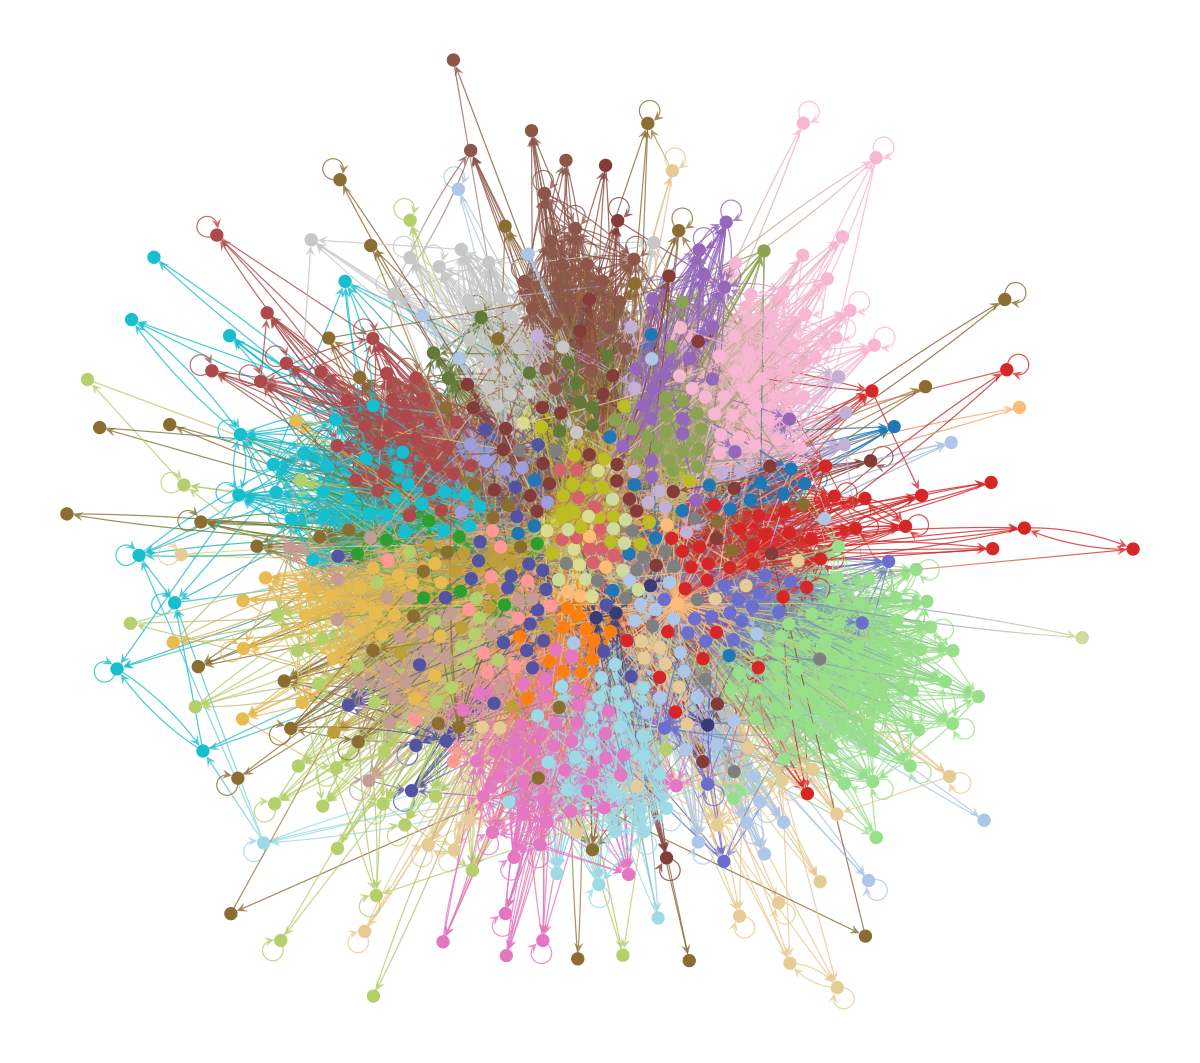

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x179a25590, at 0x17ab54440>

In [9]:
email_gt_gcc_state.draw()

## Extra:

Could we have found a better partition by changing the resolution parameter of the modulairty maximisation algorithms?

If you didn't have the ground truth partition of the network, which partition would you have chosen based on the score given by the modulairty index?

Text(0.5, 0, 'resolution')

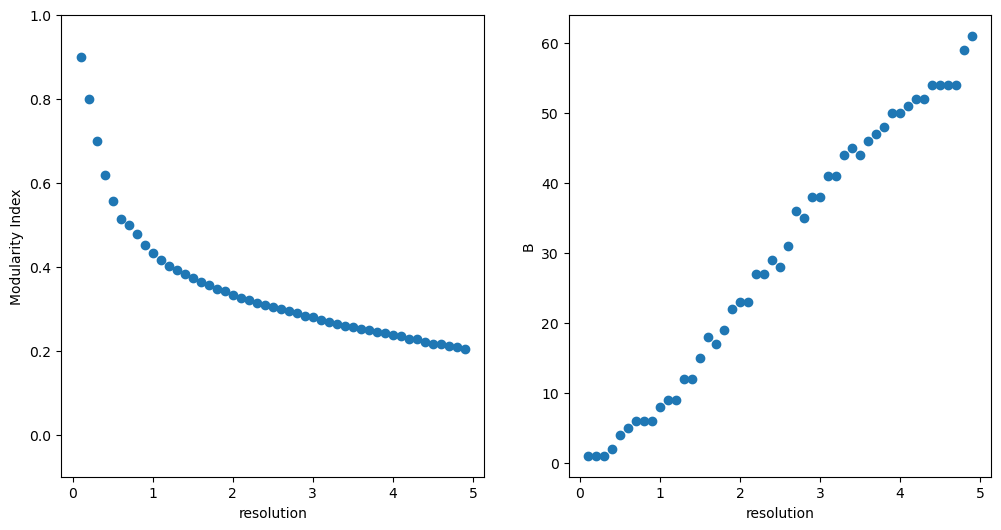

In [ ]:
# for Louvain, these are the parameters we can exeriment with:
# - resolution: if < 1, it favors large communities, > 1 small communities
# - threshold: if gain in modularity is less than the threshold, the algorithm stops
# below, we keep the threshold fixed at h = 1e-07, and systematically change the resolution

h = 1e-07
res_vals = np.arange(0.1,5,0.1)

store_modulairty = np.zeros(len(res_vals))
store_B = np.zeros(len(res_vals)) 

for i, res in enumerate(res_vals):
    
    # Louvain
    louvain_comms = nx.community.louvain_communities(email_nx_gcc, resolution=res, threshold=h)
    louvain_modularity = nx.community.modularity(email_nx_gcc, louvain_comms, resolution=res)

    # collect results
    store_B[i] = len(louvain_comms)
    store_modulairty[i] = louvain_modularity

fig, ax = plt.subplots(1, 2, figsize = (12,6))

ax[0].scatter(res_vals, store_modulairty)
ax[0].set_ylim(-0.1,1)
ax[0].set_ylabel("Modularity Index")
ax[0].set_xlabel("resolution")

ax[1].scatter(res_vals, store_B)
ax[1].set_ylabel("B")
ax[1].set_xlabel("resolution")

### modularity index of the ground truth partition

In [17]:
# to use the modularity function from networkX, we need to convert our ground truth
# memberhsip vector to a list of sets containing the nodes in each community
# we can do this using
comms = {}
for idx, label in enumerate(ground_truth_b, start=0):
    if label not in comms:
        comms[label] = set()
    comms[label].add(np.int64(idx))
ground_truth_communities = list(comms.values())

# now, we need to remove the singletons from the partition, since we are working on the giant connected component only
nodes_to_remove = set(singletons)
connected_c = [comm - nodes_to_remove for comm in ground_truth_communities if comm - nodes_to_remove]

print("make sure correct nodes have been removed: ", set().union(*connected_c) == set(email_nx_gcc.nodes()))

# compute the modulairty index using different resolutions
print([nx.community.modularity(email_nx_gcc, connected_c, resolution=i) for i in np.arange(0.1, 5.0, 0.1)])

make sure correct nodes have been removed:  True
[np.float64(0.3544153714624325), np.float64(0.34965730283428337), np.float64(0.344899234206134), np.float64(0.3401411655779848), np.float64(0.33538309694983554), np.float64(0.33062502832168633), np.float64(0.325866959693537), np.float64(0.3211088910653876), np.float64(0.3163508224372383), np.float64(0.3115927538090891), np.float64(0.3068346851809397), np.float64(0.3020766165527904), np.float64(0.29731854792464113), np.float64(0.2925604792964919), np.float64(0.2878024106683428), np.float64(0.28304434204019324), np.float64(0.2782862734120441), np.float64(0.2735282047838947), np.float64(0.2687701361557455), np.float64(0.26401206752759615), np.float64(0.259253998899447), np.float64(0.25449593027129763), np.float64(0.24973786164314837), np.float64(0.244979793014999), np.float64(0.2402217243868498), np.float64(0.23546365575870057), np.float64(0.23070558713055125), np.float64(0.225947518502402), np.float64(0.22118944987425274), np.float64(0.216

The modularity index of the ground truth partition (using any `resolution` parameter) is lower than the one we found using the modularity maximisation algorithm.

Once again, we overfitted using the descriptive methods!

### Quantifying the algorithms’ succes

below is an example of what the `adjusted_mutual_info_score` does

In [21]:
# here, we use a function that compares the ground truth partition and a given partition
# the way this work is we create a "confusion matrix" and compute the normalized mutual information measure
# this is all done automatically using the `adjusted_mutual_info_score` function, so don't worry about it!

# But we need to be able to interpret this, so here's a few examples

from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import adjusted_mutual_info_score

# Example ground truth partition
ground_truth_b_example = np.array([0, 0, 0, 1, 1, 1, 2, 2, 1])

# Some examples of predicted partitions
predicted_b_example_1 = np.array([0, 1, 1, 1, 2, 2, 2, 3, 3])
predicted_b_example_2 = np.array([1, 1, 1, 0, 0, 0, 2, 2, 0])
predicted_b_example_3 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
predicted_b_example_4 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0])

# Create the confusion (contingency) matrix
cm = contingency_matrix(ground_truth_b_example, predicted_b_example_1)
print(cm)

print("\nNMI between ground truth labels: ", adjusted_mutual_info_score(ground_truth_b_example, ground_truth_b_example))
print("NMI between example 1 labels and ground truth labels: ", adjusted_mutual_info_score(ground_truth_b_example, predicted_b_example_1))
print("NMI between example 2 labels and ground truth labels: ", adjusted_mutual_info_score(ground_truth_b_example, predicted_b_example_2))
print("NMI between example 3 labels and ground truth labels: ", adjusted_mutual_info_score(ground_truth_b_example, predicted_b_example_3))
print("NMI between example 4 labels and ground truth labels: ", adjusted_mutual_info_score(ground_truth_b_example, predicted_b_example_4))

[[1 2 0 0]
 [0 1 2 1]
 [0 0 1 1]]

NMI between ground truth labels:  1.0
NMI between example 1 labels and ground truth labels:  0.027613703233470774
NMI between example 2 labels and ground truth labels:  1.0
NMI between example 3 labels and ground truth labels:  -4.2987684430826985e-15
NMI between example 4 labels and ground truth labels:  0.0


In [22]:
def _get_b_from_communities_list(communities, nodes):
    """
    function used to translate the output of the networkX algorithm to the membership vector b as defined in the lectures
    """
    
    node_to_comm = {}
    for memerhsip, community in enumerate(communities):
        for node in community:
            node_to_comm[node] = memerhsip

    b = np.array([], dtype = int)

    for node in nodes:
        b = np.append(b, node_to_comm[node])

    return b

In [23]:
# let's first remove the singletons from the ground truth partition vector b
mask = np.ones(len(ground_truth_b), dtype=bool)
mask[singletons] = False
ground_truth_b_connected_component = ground_truth_b[mask]

print("Inferential community detection score: ", adjusted_mutual_info_score(ground_truth_b_connected_component, list(gt_b)))
print("Descriptive community detection score (using Louvain, with resolution = 1): ", adjusted_mutual_info_score(ground_truth_b_connected_component, _get_b_from_communities_list(louvain_communities, gcc)))

louvain_communities_high_res = nx.community.louvain_communities(email_nx_gcc, resolution=3, threshold=h, seed = 1)
print("Descriptive community detection score (using Louvain, with resolution = 3): ", adjusted_mutual_info_score(ground_truth_b_connected_component, _get_b_from_communities_list(louvain_communities_high_res, gcc)))

Inferential community detection score:  0.6510345993537414
Descriptive community detection score (using Louvain, with resolution = 1):  0.6011426122364736
Descriptive community detection score (using Louvain, with resolution = 3):  0.7203227599140095


## Extra Visualization

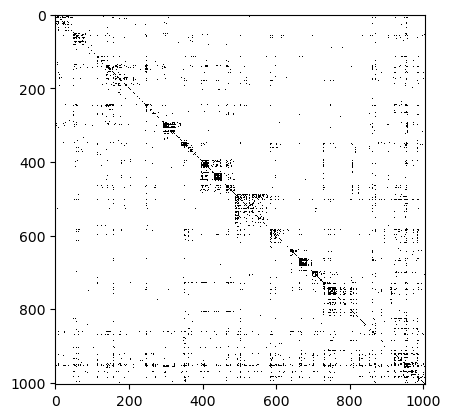

In [123]:
# visualize adjancecy ground truth network:
ordered_nodes = [[] for _ in range(42)]
for i in range(N):
    b_i = ground_truth_b_dict[i]
    ordered_nodes[b_i].append(i)

ordered_nodes = [item for sublist in ordered_nodes for item in sublist]

A = nx.adjacency_matrix(email_nx).toarray()
A_sorted = A[np.ix_(ordered_nodes,ordered_nodes)]

plt.imshow(A_sorted, cmap='Greys', interpolation='nearest')